In [3]:
%pip install pandas numpy scikit-learn xgboost matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 36.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 30.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 33.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 34.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np

In [5]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
from xgboost import XGBRegressor

In [7]:
df = pd.read_csv("../data/processed/concrete_clean.csv")
df.shape

(1005, 11)

In [8]:
feature_cols = [
    'cement',
    'slag',
    'fly_ash',
    'water',
    'superplasticizer',
    'coarse_aggregate',
    'fine_aggregate'
]

target_col = 'strength'
stage_order = ['Early', '28-day', 'Later']

In [9]:
for stage in stage_order:
    stage_df = df[df['age_stage'] == stage]
    
    print(
        stage,
        "| rows:", len(stage_df),
        "| unique mix_ids:", stage_df['mix_id'].nunique()
    )

Early | rows: 315 | unique mix_ids: 183
28-day | rows: 419 | unique mix_ids: 417
Later | rows: 271 | unique mix_ids: 140


In [10]:
stage = 'Early'

stage_df = df[df['age_stage'] == stage].copy()

X = stage_df[feature_cols]
y = stage_df[target_col]
groups = stage_df['mix_id']

In [11]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique groups:", groups.nunique())

X shape: (315, 7)
y shape: (315,)
Unique groups: 183


In [12]:
gkf = GroupKFold(n_splits=5)

In [13]:
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

In [16]:
oof_pred = np.zeros(len(stage_df))
fold_results = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    ridge_model.fit(X_train, y_train)

    pred = ridge_model.predict(X_val)

    oof_pred[val_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    fold_results.append({
        'fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [17]:
ridge_early_results = pd.DataFrame(fold_results)
ridge_early_results

,fold,RMSE,MAE,R2
0,1,6.645126,5.365605,0.617907
1,2,7.200930,5.428169,0.601714
2,3,6.227874,4.900679,0.683620
3,4,7.705797,5.944148,0.573527
4,5,8.560671,6.498696,0.640558


In [18]:
ridge_early_results[['RMSE', 'MAE', 'R2']].mean()

RMSE    7.268079
MAE     5.627459
R2      0.623466
dtype: float64

In [19]:
ridge_early_results[['RMSE', 'MAE', 'R2']].std()

RMSE    0.913372
MAE     0.611522
R2      0.041559
dtype: float64

In [20]:
overall_rmse = np.sqrt(mean_squared_error(y, oof_pred))
overall_mae = mean_absolute_error(y, oof_pred)
overall_r2 = r2_score(y, oof_pred)

print("Early - Ridge Regression")
print("OOF RMSE:", overall_rmse)
print("OOF MAE:", overall_mae)
print("OOF R²:", overall_r2)

Early - Ridge Regression
OOF RMSE: 7.313848334415826
OOF MAE: 5.627459350381117
OOF R²: 0.6308040726079585


In [21]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [23]:
rf_oof_pred = np.zeros(len(stage_df))
rf_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups), start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    rf_model.fit(X_train, y_train)

    pred = rf_model.predict(X_val)

    rf_oof_pred[val_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    rf_fold_results.append({
        'fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [24]:
rf_early_results = pd.DataFrame(rf_fold_results)
rf_early_results

,fold,RMSE,MAE,R2
0,1,7.064950,5.444154,0.568103
1,2,7.206138,5.153312,0.601138
2,3,6.006694,5.112070,0.705693
3,4,7.779267,5.613982,0.565356
4,5,9.015957,6.600758,0.601309


In [25]:
rf_early_results[['RMSE', 'MAE', 'R2']].mean()

RMSE    7.414601
MAE     5.584855
R2      0.608320
dtype: float64

In [26]:
rf_early_results[['RMSE', 'MAE', 'R2']].std()

RMSE    1.100595
MAE     0.604661
R2      0.057109
dtype: float64

In [27]:
rf_overall_rmse = np.sqrt(mean_squared_error(y, rf_oof_pred))
rf_overall_mae = mean_absolute_error(y, rf_oof_pred)
rf_overall_r2 = r2_score(y, rf_oof_pred)

print("Early - Random Forest")
print("OOF RMSE:", rf_overall_rmse)
print("OOF MAE:", rf_overall_mae)
print("OOF R²:", rf_overall_r2)

Early - Random Forest
OOF RMSE: 7.479662767775335
OOF MAE: 5.584855051880331
OOF R²: 0.6138740088236248


In [28]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

In [30]:
xgb_oof_pred = np.zeros(len(stage_df))
xgb_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups), start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    xgb_model.fit(X_train, y_train)

    pred = xgb_model.predict(X_val)

    xgb_oof_pred[val_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    xgb_fold_results.append({
        'fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [31]:
xgb_early_results = pd.DataFrame(xgb_fold_results)
xgb_early_results

,fold,RMSE,MAE,R2
0,1,7.188030,5.561967,0.552923
1,2,7.325349,5.447085,0.587832
2,3,5.813363,4.929864,0.724333
3,4,7.608905,5.707503,0.584185
4,5,8.427845,6.291524,0.651626


In [32]:
xgb_early_results[['RMSE', 'MAE', 'R2']].mean()

RMSE    7.272698
MAE     5.587588
R2      0.620180
dtype: float64

In [33]:
xgb_overall_rmse = np.sqrt(mean_squared_error(y, xgb_oof_pred))
xgb_overall_mae = mean_absolute_error(y, xgb_oof_pred)
xgb_overall_r2 = r2_score(y, xgb_oof_pred)

print("Early - XGBoost")
print("OOF RMSE:", xgb_overall_rmse)
print("OOF MAE:", xgb_overall_mae)
print("OOF R²:", xgb_overall_r2)

Early - XGBoost
OOF RMSE: 7.321853600931855
OOF MAE: 5.587588446234894
OOF R²: 0.629995434223223


In [34]:
early_model_comparison = pd.DataFrame({
    'Model': ['Ridge', 'Random Forest', 'XGBoost'],
    'RMSE': [
        overall_rmse,
        rf_overall_rmse,
        xgb_overall_rmse
    ],
    'MAE': [
        overall_mae,
        rf_overall_mae,
        xgb_overall_mae
    ],
    'R2': [
        overall_r2,
        rf_overall_r2,
        xgb_overall_r2
    ]
})

early_model_comparison

,Model,RMSE,MAE,R2
0,Ridge,7.313848,5.627459,0.630804
1,Random Forest,7.479663,5.584855,0.613874
2,XGBoost,7.321854,5.587588,0.629995


In [35]:
stage = '28-day'

stage_df = df[df['age_stage'] == stage].copy()

X = stage_df[feature_cols]
y = stage_df[target_col]
groups = stage_df['mix_id']

In [36]:
print("Stage:", stage)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique groups:", groups.nunique())

Stage: 28-day
X shape: (419, 7)
y shape: (419,)
Unique groups: 417


In [37]:
gkf = GroupKFold(n_splits=5)

In [38]:
ridge_28_oof_pred = np.zeros(len(stage_df))
ridge_28_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups), start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    ridge_model.fit(X_train, y_train)

    pred = ridge_model.predict(X_val)

    ridge_28_oof_pred[val_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    ridge_28_fold_results.append({
        'fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [39]:
ridge_28_results = pd.DataFrame(ridge_28_fold_results)
ridge_28_results

,fold,RMSE,MAE,R2
0,1,6.565325,5.164010,0.794010
1,2,7.323839,5.300936,0.702218
2,3,6.463869,5.069133,0.797446
3,4,7.622972,5.677134,0.732905
4,5,7.607037,5.483650,0.727197


In [40]:
ridge_28_results[['RMSE', 'MAE', 'R2']].mean()

RMSE    7.116609
MAE     5.338972
R2      0.750755
dtype: float64

In [41]:
ridge_28_rmse = np.sqrt(mean_squared_error(y, ridge_28_oof_pred))
ridge_28_mae = mean_absolute_error(y, ridge_28_oof_pred)
ridge_28_r2 = r2_score(y, ridge_28_oof_pred)

print("28-day - Ridge Regression")
print("OOF RMSE:", ridge_28_rmse)
print("OOF MAE:", ridge_28_mae)
print("OOF R²:", ridge_28_r2)

28-day - Ridge Regression
OOF RMSE: 7.133264418712669
OOF MAE: 5.338627205973259
OOF R²: 0.754201377472792


In [43]:
rf_28_oof_pred = np.zeros(len(stage_df))
rf_28_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups), start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    rf_model.fit(X_train, y_train)

    pred = rf_model.predict(X_val)

    rf_28_oof_pred[val_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    rf_28_fold_results.append({
        'fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [44]:
rf_28_results = pd.DataFrame(rf_28_fold_results)
rf_28_results

,fold,RMSE,MAE,R2
0,1,5.720813,3.975816,0.843595
1,2,5.760375,3.686918,0.815786
2,3,4.972081,3.381416,0.880152
3,4,6.197158,3.930423,0.823477
4,5,5.828415,3.935272,0.839853


In [45]:
rf_28_results[['RMSE', 'MAE', 'R2']].mean()

RMSE    5.695768
MAE     3.781969
R2      0.840573
dtype: float64

In [46]:
rf_28_rmse = np.sqrt(mean_squared_error(y, rf_28_oof_pred))
rf_28_mae = mean_absolute_error(y, rf_28_oof_pred)
rf_28_r2 = r2_score(y, rf_28_oof_pred)

print("28-day - Random Forest")
print("OOF RMSE:", rf_28_rmse)
print("OOF MAE:", rf_28_mae)
print("OOF R²:", rf_28_r2)

28-day - Random Forest
OOF RMSE: 5.709466661168431
OOF MAE: 3.7816032015961243
OOF R²: 0.8425314307204994


In [48]:
xgb_28_oof_pred = np.zeros(len(stage_df))
xgb_28_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups), start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    xgb_model.fit(X_train, y_train)

    pred = xgb_model.predict(X_val)

    xgb_28_oof_pred[val_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    xgb_28_fold_results.append({
        'fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [49]:
xgb_28_results = pd.DataFrame(xgb_28_fold_results)
xgb_28_results

,fold,RMSE,MAE,R2
0,1,5.567034,4.090069,0.851891
1,2,5.928374,3.862231,0.804884
2,3,5.090429,3.596316,0.874378
3,4,6.058609,4.126575,0.831282
4,5,5.665833,3.787498,0.848663


In [50]:
xgb_28_results[['RMSE', 'MAE', 'R2']].mean()

RMSE    5.662056
MAE     3.892538
R2      0.842220
dtype: float64

In [51]:
xgb_28_rmse = np.sqrt(mean_squared_error(y, xgb_28_oof_pred))
xgb_28_mae = mean_absolute_error(y, xgb_28_oof_pred)
xgb_28_r2 = r2_score(y, xgb_28_oof_pred)

print("28-day - XGBoost")
print("OOF RMSE:", xgb_28_rmse)
print("OOF MAE:", xgb_28_mae)
print("OOF R²:", xgb_28_r2)

28-day - XGBoost
OOF RMSE: 5.672022763809338
OOF MAE: 3.8927882948420978
OOF R²: 0.8445900827473308


In [52]:
day28_model_comparison = pd.DataFrame({
    'Model': ['Ridge', 'Random Forest', 'XGBoost'],
    'RMSE': [
        ridge_28_rmse,
        rf_28_rmse,
        xgb_28_rmse
    ],
    'MAE': [
        ridge_28_mae,
        rf_28_mae,
        xgb_28_mae
    ],
    'R2': [
        ridge_28_r2,
        rf_28_r2,
        xgb_28_r2
    ]
})

day28_model_comparison

,Model,RMSE,MAE,R2
0,Ridge,7.133264,5.338627,0.754201
1,Random Forest,5.709467,3.781603,0.842531
2,XGBoost,5.672023,3.892788,0.844590


In [53]:
stage = 'Later'

stage_df = df[df['age_stage'] == stage].copy()

X = stage_df[feature_cols]
y = stage_df[target_col]
groups = stage_df['mix_id']

In [54]:
print("Stage:", stage)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique groups:", groups.nunique())

Stage: Later
X shape: (271, 7)
y shape: (271,)
Unique groups: 140


In [55]:
gkf = GroupKFold(n_splits=5)

In [56]:
ridge_later_oof_pred = np.zeros(len(stage_df))
ridge_later_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups), start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    ridge_model.fit(X_train, y_train)

    pred = ridge_model.predict(X_val)

    ridge_later_oof_pred[val_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    ridge_later_fold_results.append({
        'fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [57]:
ridge_later_results = pd.DataFrame(ridge_later_fold_results)
ridge_later_results

,fold,RMSE,MAE,R2
0,1,8.820297,7.043988,0.682708
1,2,7.083246,5.547659,0.631845
2,3,6.502844,5.007310,0.639669
3,4,7.606487,5.935429,0.490032
4,5,7.425267,6.099241,0.721934


In [58]:
ridge_later_results[['RMSE', 'MAE', 'R2']].mean()

RMSE    7.487628
MAE     5.926725
R2      0.633238
dtype: float64

In [59]:
ridge_later_rmse = np.sqrt(
    mean_squared_error(y, ridge_later_oof_pred)
)

ridge_later_mae = mean_absolute_error(
    y, ridge_later_oof_pred
)

ridge_later_r2 = r2_score(
    y, ridge_later_oof_pred
)

print("Later - Ridge Regression")
print("OOF RMSE:", ridge_later_rmse)
print("OOF MAE:", ridge_later_mae)
print("OOF R²:", ridge_later_r2)

Later - Ridge Regression
OOF RMSE: 7.531804526273553
OOF MAE: 5.930848185584154
OOF R²: 0.6523205369011262


In [60]:
rf_later_oof_pred = np.zeros(len(stage_df))
rf_later_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups), start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    rf_model.fit(X_train, y_train)

    pred = rf_model.predict(X_val)

    rf_later_oof_pred[val_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    rf_later_fold_results.append({
        'fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [61]:
rf_later_results = pd.DataFrame(rf_later_fold_results)
rf_later_results

,fold,RMSE,MAE,R2
0,1,6.870632,5.483338,0.807476
1,2,7.157023,5.520975,0.624136
2,3,5.360049,4.176035,0.755188
3,4,5.524440,4.041543,0.731001
4,5,5.955514,4.636800,0.821120


In [62]:
rf_later_results[['RMSE', 'MAE', 'R2']].mean()

RMSE    6.173531
MAE     4.771738
R2      0.747784
dtype: float64

In [63]:
rf_later_rmse = np.sqrt(mean_squared_error(y, rf_later_oof_pred))
rf_later_mae = mean_absolute_error(y, rf_later_oof_pred)
rf_later_r2 = r2_score(y, rf_later_oof_pred)

print("Later - Random Forest")
print("OOF RMSE:", rf_later_rmse)
print("OOF MAE:", rf_later_mae)
print("OOF R²:", rf_later_r2)

Later - Random Forest
OOF RMSE: 6.217788891473046
OOF MAE: 4.7743640412651445
OOF R²: 0.7630520786263251


In [64]:
xgb_later_oof_pred = np.zeros(len(stage_df))
xgb_later_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups), start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    xgb_model.fit(X_train, y_train)

    pred = xgb_model.predict(X_val)

    xgb_later_oof_pred[val_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    xgb_later_fold_results.append({
        'fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [65]:
xgb_later_results = pd.DataFrame(xgb_later_fold_results)
xgb_later_results

,fold,RMSE,MAE,R2
0,1,6.775124,5.374389,0.812791
1,2,7.056811,5.473592,0.634588
2,3,4.737314,3.694322,0.808768
3,4,5.053562,3.655993,0.774903
4,5,5.647574,4.548932,0.839140


In [66]:
xgb_later_results[['RMSE', 'MAE', 'R2']].mean()

RMSE    5.854077
MAE     4.549446
R2      0.774038
dtype: float64

In [67]:
xgb_later_results[['RMSE', 'MAE', 'R2']].mean()

RMSE    5.854077
MAE     4.549446
R2      0.774038
dtype: float64

In [68]:
xgb_later_rmse = np.sqrt(mean_squared_error(y, xgb_later_oof_pred))
xgb_later_mae = mean_absolute_error(y, xgb_later_oof_pred)
xgb_later_r2 = r2_score(y, xgb_later_oof_pred)

print("Later - XGBoost")
print("OOF RMSE:", xgb_later_rmse)
print("OOF MAE:", xgb_later_mae)
print("OOF R²:", xgb_later_r2)

Later - XGBoost
OOF RMSE: 5.9291759043090355
OOF MAE: 4.552489907459126
OOF R²: 0.7845385253339017


In [69]:
model_comparison = pd.DataFrame({
    'Stage': [
        'Early', 'Early', 'Early',
        '28-day', '28-day', '28-day',
        'Later', 'Later', 'Later'
    ],
    
    'Model': [
        'Ridge', 'Random Forest', 'XGBoost',
        'Ridge', 'Random Forest', 'XGBoost',
        'Ridge', 'Random Forest', 'XGBoost'
    ],
    
    'RMSE': [
        overall_rmse,
        rf_overall_rmse,
        xgb_overall_rmse,
        ridge_28_rmse,
        rf_28_rmse,
        xgb_28_rmse,
        ridge_later_rmse,
        rf_later_rmse,
        xgb_later_rmse
    ],
    
    'MAE': [
        overall_mae,
        rf_overall_mae,
        xgb_overall_mae,
        ridge_28_mae,
        rf_28_mae,
        xgb_28_mae,
        ridge_later_mae,
        rf_later_mae,
        xgb_later_mae
    ],
    
    'R2': [
        overall_r2,
        rf_overall_r2,
        xgb_overall_r2,
        ridge_28_r2,
        rf_28_r2,
        xgb_28_r2,
        ridge_later_r2,
        rf_later_r2,
        xgb_later_r2
    ]
})

model_comparison.round(3)

,Stage,Model,RMSE,MAE,R2
0,Early,Ridge,7.314,5.627,0.631
1,Early,Random Forest,7.480,5.585,0.614
2,Early,XGBoost,7.322,5.588,0.630
3,28-day,Ridge,7.133,5.339,0.754
4,28-day,Random Forest,5.709,3.782,0.843
5,28-day,XGBoost,5.672,3.893,0.845
6,Later,Ridge,7.532,5.931,0.652
7,Later,Random Forest,6.218,4.774,0.763
8,Later,XGBoost,5.929,4.552,0.785


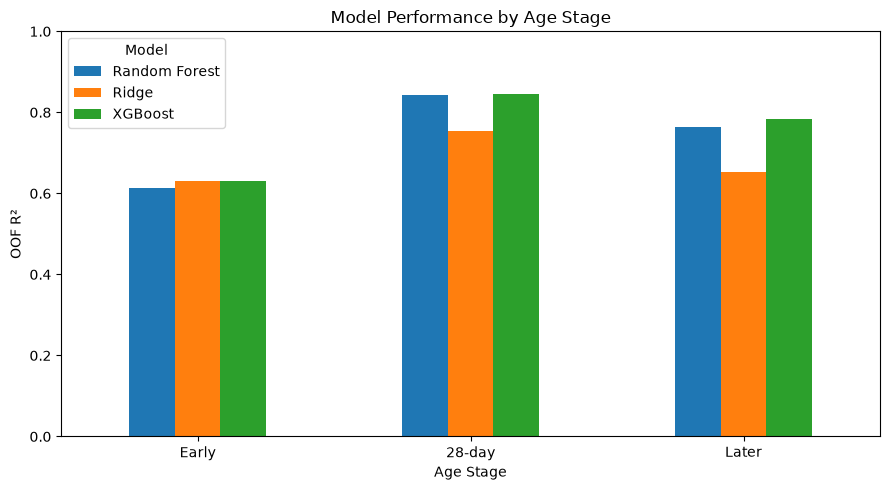

In [70]:
import matplotlib.pyplot as plt

r2_table = model_comparison.pivot(
    index='Stage',
    columns='Model',
    values='R2'
).reindex(['Early', '28-day', 'Later'])

r2_table.plot(kind='bar', figsize=(9,5))

plt.title('Model Performance by Age Stage')
plt.xlabel('Age Stage')
plt.ylabel('OOF R²')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

In [71]:
from sklearn.model_selection import RandomizedSearchCV

In [72]:
xgb_param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [73]:
stage = 'Early'

stage_df = df[df['age_stage'] == stage].copy()

X = stage_df[feature_cols]
y = stage_df[target_col]
groups = stage_df['mix_id']

In [74]:
xgb_tune_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

In [75]:
gkf_tune = GroupKFold(n_splits=5)

xgb_search = RandomizedSearchCV(
    estimator=xgb_tune_model,
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=gkf_tune,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [76]:
xgb_search.fit(
    X,
    y,
    groups=groups
)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [200, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best es

In [77]:
xgb_search.best_params_

{'subsample': 1.0,
 'n_estimators': 200,
 'max_depth': 3,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [78]:
-xgb_search.best_score_

np.float64(7.261865888265106)

In [79]:
xgb_early_tuned = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

In [81]:
tuned_early_oof_pred = np.zeros(len(stage_df))
tuned_early_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups), start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    xgb_early_tuned.fit(X_train, y_train)

    pred = xgb_early_tuned.predict(X_val)

    tuned_early_oof_pred[val_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    tuned_early_fold_results.append({
        'fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

In [82]:
tuned_early_results = pd.DataFrame(tuned_early_fold_results)
tuned_early_results

,fold,RMSE,MAE,R2
0,1,7.138432,5.553854,0.559072
1,2,7.323186,5.436235,0.588076
2,3,5.827934,4.926657,0.722950
3,4,7.612244,5.688912,0.583820
4,5,8.407533,6.310126,0.653303


In [83]:
tuned_early_rmse = np.sqrt(
    mean_squared_error(y, tuned_early_oof_pred)
)

tuned_early_mae = mean_absolute_error(
    y, tuned_early_oof_pred
)

tuned_early_r2 = r2_score(
    y, tuned_early_oof_pred
)

print("Early - Tuned XGBoost")
print("OOF RMSE:", tuned_early_rmse)
print("OOF MAE:", tuned_early_mae)
print("OOF R²:", tuned_early_r2)

Early - Tuned XGBoost
OOF RMSE: 7.310047255105211
OOF MAE: 5.583156878726548
OOF R²: 0.6311877224380905


In [84]:
print(stage)
print(X.shape)

Early
(315, 7)


In [85]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

In [86]:
model_comparison.round(3)

,Stage,Model,RMSE,MAE,R2
0,Early,Ridge,7.314,5.627,0.631
1,Early,Random Forest,7.480,5.585,0.614
2,Early,XGBoost,7.322,5.588,0.630
3,28-day,Ridge,7.133,5.339,0.754
4,28-day,Random Forest,5.709,3.782,0.843
5,28-day,XGBoost,5.672,3.893,0.845
6,Later,Ridge,7.532,5.931,0.652
7,Later,Random Forest,6.218,4.774,0.763
8,Later,XGBoost,5.929,4.552,0.785


In [87]:
model_comparison.to_csv(
    "../data/processed/model_performance.csv",
    index=False
)

In [88]:
pd.read_csv("../data/processed/model_performance.csv")

,Stage,Model,RMSE,MAE,R2
0,Early,Ridge,7.313848,5.627459,0.630804
1,Early,Random Forest,7.479663,5.584855,0.613874
2,Early,XGBoost,7.321854,5.587588,0.629995
3,28-day,Ridge,7.133264,5.338627,0.754201
4,28-day,Random Forest,5.709467,3.781603,0.842531
5,28-day,XGBoost,5.672023,3.892788,0.844590
6,Later,Ridge,7.531805,5.930848,0.652321
7,Later,Random Forest,6.217789,4.774364,0.763052
8,Later,XGBoost,5.929176,4.552490,0.784539
